# PACO VIP-fork - Comparador final CPU vs GPU (ALL datasets)



In [1]:
# Setup y carga de artefactos desde Drive
import json
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

try:
    from google.colab import drive
    if not Path('/content/drive/MyDrive').exists():
        drive.mount('/content/drive', force_remount=False)
    else:
        print('[INFO] Drive ya disponible en /content/drive/MyDrive')
except Exception as exc:
    print(f"[INFO] Entorno no-Colab o Drive ya montado: {exc}")

DRIVE_ROOT = Path('/content/drive/MyDrive')
if not DRIVE_ROOT.exists():
    DRIVE_ROOT = Path.cwd()

BASE_DIR = DRIVE_ROOT / 'paco_benchmarks'
CPU_DIR = BASE_DIR / 'cpu_all'
GPU_DIR = BASE_DIR / 'gpu_all'
OUT_DIR = BASE_DIR / 'compare_all'
OUT_DIR.mkdir(parents=True, exist_ok=True)

paths = {
    'cpu_bench': CPU_DIR / 'benchmark_results_cpu_all.csv',
    'gpu_bench': GPU_DIR / 'benchmark_results_gpu_all.csv',
    'cpu_meta': CPU_DIR / 'metadata_cpu_all.json',
    'gpu_meta': GPU_DIR / 'metadata_gpu_all.json',
    'cpu_profile': CPU_DIR / 'profile_cpu_all.csv',
    'gpu_profile': GPU_DIR / 'profile_gpu_all.csv',
}

missing = [k for k, p in paths.items() if not p.exists() and k not in ('cpu_profile', 'gpu_profile')]
if missing:
    raise RuntimeError(
        'Faltan artefactos requeridos. Ejecuta primero los notebooks CPU y GPU.\n'
        + '\n'.join([f'- {k}: {paths[k]}' for k in missing])
    )

cpu_df = pd.read_csv(paths['cpu_bench'])
gpu_df = pd.read_csv(paths['gpu_bench'])
with open(paths['cpu_meta']) as f:
    cpu_meta = json.load(f)
with open(paths['gpu_meta']) as f:
    gpu_meta = json.load(f)

cpu_profile_df = pd.read_csv(paths['cpu_profile']) if paths['cpu_profile'].exists() else pd.DataFrame()
gpu_profile_df = pd.read_csv(paths['gpu_profile']) if paths['gpu_profile'].exists() else pd.DataFrame()

# CSV extra (opcionales) generados por notebooks CPU/GPU
cpu_extra_paths = {
    'extra_metrics': CPU_DIR / 'extra_metrics_cpu_all.csv',
    'instrument_metrics': CPU_DIR / 'instrument_metrics_cpu_all.csv',
    'global_metrics': CPU_DIR / 'global_metrics_cpu_all.csv',
}
gpu_extra_paths = {
    'extra_metrics': GPU_DIR / 'extra_metrics_gpu_all.csv',
    'instrument_metrics': GPU_DIR / 'instrument_metrics_gpu_all.csv',
    'global_metrics': GPU_DIR / 'global_metrics_gpu_all.csv',
}

cpu_extra_metrics_df = pd.read_csv(cpu_extra_paths['extra_metrics']) if cpu_extra_paths['extra_metrics'].exists() else pd.DataFrame()
gpu_extra_metrics_df = pd.read_csv(gpu_extra_paths['extra_metrics']) if gpu_extra_paths['extra_metrics'].exists() else pd.DataFrame()
cpu_instrument_metrics_df = pd.read_csv(cpu_extra_paths['instrument_metrics']) if cpu_extra_paths['instrument_metrics'].exists() else pd.DataFrame()
gpu_instrument_metrics_df = pd.read_csv(gpu_extra_paths['instrument_metrics']) if gpu_extra_paths['instrument_metrics'].exists() else pd.DataFrame()
cpu_global_metrics_df = pd.read_csv(cpu_extra_paths['global_metrics']) if cpu_extra_paths['global_metrics'].exists() else pd.DataFrame()
gpu_global_metrics_df = pd.read_csv(gpu_extra_paths['global_metrics']) if gpu_extra_paths['global_metrics'].exists() else pd.DataFrame()

print(f"DRIVE_ROOT: {DRIVE_ROOT}")
print(f"CPU_DIR: {CPU_DIR}")
print(f"GPU_DIR: {GPU_DIR}")
print(f"OUT_DIR: {OUT_DIR}")
print('[OK] Artefactos cargados')

Mounted at /content/drive
DRIVE_ROOT: /content/drive/MyDrive
CPU_DIR: /content/drive/MyDrive/paco_benchmarks/cpu_all
GPU_DIR: /content/drive/MyDrive/paco_benchmarks/gpu_all
OUT_DIR: /content/drive/MyDrive/paco_benchmarks/compare_all
[OK] Artefactos cargados


In [2]:
# Clasificacion del experimento: equivalencia 1:1 vs benchmark de implementaciones
cpu_fp = cpu_meta.get('hp_fingerprint', '')
gpu_fp = gpu_meta.get('hp_fingerprint', '')
fp_match = cpu_fp == gpu_fp and len(cpu_fp) > 0

cpu_hp = cpu_meta.get('locked_hparams', {})
gpu_hp = gpu_meta.get('locked_hparams', {})

cpu_impl = str(cpu_hp.get('paco_impl', cpu_meta.get('paco_impl', 'desconocido')))
gpu_impl = str(gpu_hp.get('paco_impl', gpu_meta.get('paco_impl', 'desconocido')))
impl_match = (cpu_impl == gpu_impl) and (cpu_impl != 'desconocido')

comparison_mode = 'equivalencia_1to1' if (fp_match and impl_match) else 'benchmark_implementaciones'

hp_rows = []
all_keys = sorted(set(cpu_hp.keys()) | set(gpu_hp.keys()))
for k in all_keys:
    hp_rows.append({
        'Parametro': k,
        'CPU': str(cpu_hp.get(k, 'N/A')),
        'GPU': str(gpu_hp.get(k, 'N/A')),
        'Igual': 'SI' if cpu_hp.get(k, None) == gpu_hp.get(k, '__DIFF__') else 'NO',
    })

hp_df = pd.DataFrame(hp_rows)

print('Fingerprint CPU:', cpu_fp[:20])
print('Fingerprint GPU:', gpu_fp[:20])
print('Fingerprint match:', fp_match)
print('PACO impl CPU:', cpu_impl)
print('PACO impl GPU:', gpu_impl)
print('PACO impl match:', impl_match)
print('Modo de comparacion:', comparison_mode)

display(hp_df)

if comparison_mode == 'equivalencia_1to1':
    print('[OK] Comparacion valida 1:1 (hiperparametros + implementacion PACO coinciden).')
else:
    print('[WARNING] Comparacion clasificada como benchmark entre implementaciones (NO 1:1).')

Fingerprint CPU: a8300ca1fa4e334233ff
Fingerprint GPU: 25fcf8c2186ee856dfe4
Fingerprint match: False
PACO impl CPU: desconocido
PACO impl GPU: desconocido
PACO impl match: False
Modo de comparacion: benchmark_implementaciones


,Parametro,CPU,GPU,Igual
0,benchmark_pixels,2500,2500,SI
1,cpu_threads,1,1,SI
2,crop_half_size,75,75,SI
3,datasets,"['lmircam_1', 'lmircam_2', 'lmircam_3', 'nirc2...","['lmircam_1', 'lmircam_2', 'nirc2_1', 'nirc2_2...",NO
4,frame_stride,1,1,SI
5,inner_radius,8,8,SI
6,outer_radius,55,55,SI
7,profile_dataset,lmircam_1,lmircam_1,SI
8,profile_pixels,120,120,SI
9,snr_thresholds,"[3, 5, 7]","[3, 5, 7]",SI


[WARNING] Comparacion clasificada como benchmark entre implementaciones (NO 1:1).


In [3]:
# Tabla consolidada CPU vs GPU, separando equivalencia 1:1 y benchmark de implementaciones
merged = cpu_df.merge(gpu_df, on='Dataset', suffixes=('_cpu', '_gpu'))

merged['Speedup CPU/GPU'] = merged['Tiempo (s)_cpu'] / merged['Tiempo (s)_gpu']
merged['Delta SNR max (GPU-CPU)'] = merged['SNR max_gpu'] - merged['SNR max_cpu']
merged['Delta SNR mean (GPU-CPU)'] = merged['SNR mean_gpu'] - merged['SNR mean_cpu']
merged['Delta SNR>3 (GPU-CPU)'] = merged['SNR>3_gpu'] - merged['SNR>3_cpu']
merged['Delta SNR>5 (GPU-CPU)'] = merged['SNR>5_gpu'] - merged['SNR>5_cpu']
merged['Delta SNR>7 (GPU-CPU)'] = merged['SNR>7_gpu'] - merged['SNR>7_cpu']

# Tolerancias cientificas (solo aplican a equivalencia 1:1)
SNR_MAX_TOL = 1.0
SNR_MEAN_TOL = 0.2

if comparison_mode == 'equivalencia_1to1':
    merged['Robustez SNR'] = np.where(
        (np.abs(merged['Delta SNR max (GPU-CPU)']) <= SNR_MAX_TOL) &
        (np.abs(merged['Delta SNR mean (GPU-CPU)']) <= SNR_MEAN_TOL),
        'OK',
        'REVISAR'
    )
    merged['Validez cientifica 1:1'] = 'SI'
else:
    merged['Robustez SNR'] = 'N/A (implementaciones distintas)'
    merged['Validez cientifica 1:1'] = 'NO'

cols = [
    'Dataset',
    'Tiempo (s)_cpu', 'Tiempo (s)_gpu', 'Speedup CPU/GPU',
    'SNR max_cpu', 'SNR max_gpu', 'Delta SNR max (GPU-CPU)',
    'SNR mean_cpu', 'SNR mean_gpu', 'Delta SNR mean (GPU-CPU)',
    'Delta SNR>3 (GPU-CPU)', 'Delta SNR>5 (GPU-CPU)', 'Delta SNR>7 (GPU-CPU)',
    'Robustez SNR', 'Validez cientifica 1:1'
]

display(merged[cols])

total_cpu = float(merged['Tiempo (s)_cpu'].sum())
total_gpu = float(merged['Tiempo (s)_gpu'].sum())
speedup_global = total_cpu / total_gpu if total_gpu > 0 else np.nan

print('\nResumen global:')
print(f'  Tipo de comparacion: {comparison_mode}')
print(f'  Tiempo total CPU: {total_cpu:.2f} s')
print(f'  Tiempo total GPU: {total_gpu:.2f} s')
print(f'  Speedup global CPU/GPU: {speedup_global:.2f}x')

if comparison_mode == 'equivalencia_1to1':
    print(f"  Datasets robustos SNR: {(merged['Robustez SNR'] == 'OK').sum()}/{len(merged)}")
else:
    print('  Robustez SNR: N/A (benchmark entre implementaciones).')

,Dataset,Tiempo (s)_cpu,Tiempo (s)_gpu,Speedup CPU/GPU,SNR max_cpu,SNR max_gpu,Delta SNR max (GPU-CPU),SNR mean_cpu,SNR mean_gpu,Delta SNR mean (GPU-CPU),Delta SNR>3 (GPU-CPU),Delta SNR>5 (GPU-CPU),Delta SNR>7 (GPU-CPU),Robustez SNR,Validez cientifica 1:1
0,lmircam_1,1373.475018,182.575590,7.522775,25.715198,25.715438,0.000240,0.111142,0.111139,-2.964683e-06,0,0,0,N/A (implementaciones distintas),NO
1,lmircam_2,910.716368,155.300628,5.864216,23.651627,23.651645,0.000018,0.039608,0.039606,-2.716047e-06,0,0,0,N/A (implementaciones distintas),NO
2,nirc2_1,10.603685,1.658154,6.394872,2.904008,2.904019,0.000011,0.051992,0.051992,-2.017495e-08,0,0,0,N/A (implementaciones distintas),NO
3,nirc2_2,12.723016,1.884922,6.749889,4.294977,4.294990,0.000013,-0.017077,-0.017078,-8.483233e-07,0,0,0,N/A (implementaciones distintas),NO
4,nirc2_3,14.533363,2.180586,6.664888,3.696830,3.696821,-0.000009,0.004761,0.004761,3.301201e-07,0,0,0,N/A (implementaciones distintas),NO
5,sphere_irdis_1,66.422946,9.453779,7.026073,5.860323,5.860361,0.000039,0.031135,0.031133,-1.956653e-06,0,0,0,N/A (implementaciones distintas),NO
6,sphere_irdis_2,22.699695,3.052288,7.436943,4.867606,4.867620,0.000014,-0.006804,-0.006805,-1.049066e-06,0,0,0,N/A (implementaciones distintas),NO
7,sphere_irdis_3,59.765679,8.152415,7.331040,17.032870,17.032849,-0.000021,0.019241,0.019241,-3.022711e-07,0,0,0,N/A (implementaciones distintas),NO



Resumen global:
  Tipo de comparacion: benchmark_implementaciones
  Tiempo total CPU: 2470.94 s
  Tiempo total GPU: 364.26 s
  Speedup global CPU/GPU: 6.78x
  Robustez SNR: N/A (benchmark entre implementaciones).


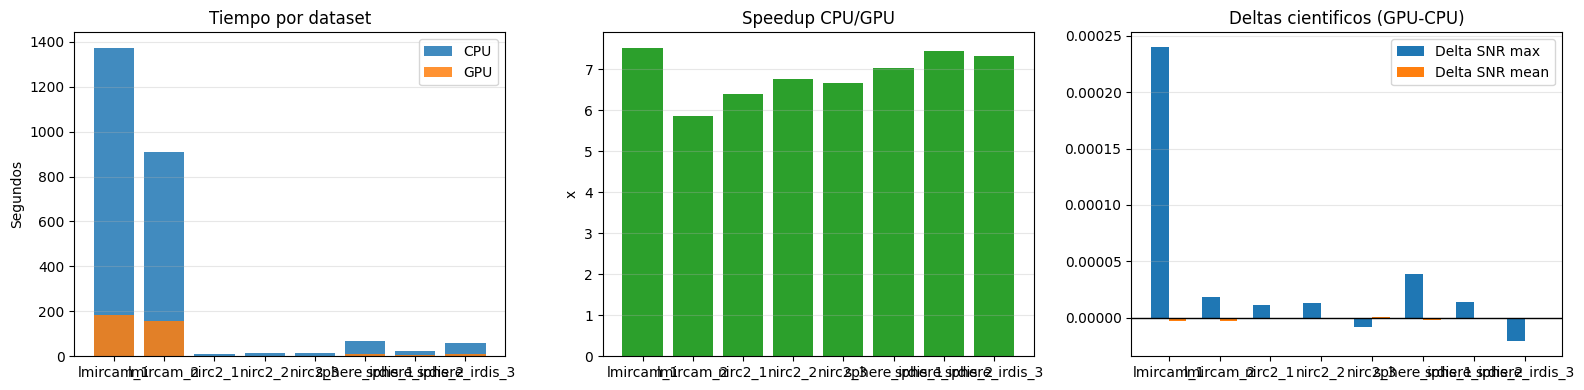

[OK] Figura guardada: /content/drive/MyDrive/paco_benchmarks/compare_all/final_cpu_vs_gpu_summary.png


In [4]:
# Graficos comparativos finales
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].bar(merged['Dataset'], merged['Tiempo (s)_cpu'], label='CPU', alpha=0.85)
axes[0].bar(merged['Dataset'], merged['Tiempo (s)_gpu'], label='GPU', alpha=0.85)
axes[0].set_title('Tiempo por dataset')
axes[0].set_ylabel('Segundos')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(merged['Dataset'], merged['Speedup CPU/GPU'], color='#2ca02c')
axes[1].set_title('Speedup CPU/GPU')
axes[1].set_ylabel('x')
axes[1].grid(axis='y', alpha=0.3)

x = np.arange(len(merged))
w = 0.35
axes[2].bar(x - w/2, merged['Delta SNR max (GPU-CPU)'], width=w, label='Delta SNR max')
axes[2].bar(x + w/2, merged['Delta SNR mean (GPU-CPU)'], width=w, label='Delta SNR mean')
axes[2].axhline(0, color='black', lw=1)
axes[2].set_xticks(x)
axes[2].set_xticklabels(merged['Dataset'].tolist())
axes[2].set_title('Deltas cientificos (GPU-CPU)')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
fig_path = OUT_DIR / 'final_cpu_vs_gpu_summary.png'
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'[OK] Figura guardada: {fig_path}')

In [5]:
# Metricas extras por tipo de comparacion + perfilado
extra_metric_files = []
merged['Instrumento'] = merged['Dataset'].apply(lambda x: '_'.join(str(x).split('_')[:-1]))

eps = 1e-12
if comparison_mode == 'equivalencia_1to1':
    merged['Abs Delta SNR max'] = np.abs(merged['Delta SNR max (GPU-CPU)'])
    merged['Abs Delta SNR mean'] = np.abs(merged['Delta SNR mean (GPU-CPU)'])
    merged['Rel Delta SNR max (%)'] = 100.0 * merged['Abs Delta SNR max'] / (np.abs(merged['SNR max_cpu']) + eps)
    merged['Rel Delta SNR mean (%)'] = 100.0 * merged['Abs Delta SNR mean'] / (np.abs(merged['SNR mean_cpu']) + eps)

    STRICT_MAX_TOL = 0.5
    STRICT_MEAN_TOL = 0.05
    merged['Robustez SNR (estricta)'] = np.where(
        (merged['Abs Delta SNR max'] <= STRICT_MAX_TOL) &
        (merged['Abs Delta SNR mean'] <= STRICT_MEAN_TOL),
        'OK',
        'REVISAR'
    )

    corr_snr_max = float(np.corrcoef(merged['SNR max_cpu'], merged['SNR max_gpu'])[0, 1]) if len(merged) > 1 else np.nan
    corr_snr_mean = float(np.corrcoef(merged['SNR mean_cpu'], merged['SNR mean_gpu'])[0, 1]) if len(merged) > 1 else np.nan

    equivalence_summary_df = pd.DataFrame([{
        'n_datasets': int(len(merged)),
        'corr_snr_max_cpu_gpu': corr_snr_max,
        'corr_snr_mean_cpu_gpu': corr_snr_mean,
        'mae_snr_max': float(merged['Abs Delta SNR max'].mean()),
        'mae_snr_mean': float(merged['Abs Delta SNR mean'].mean()),
        'pass_base_tol': int((merged['Robustez SNR'] == 'OK').sum()),
        'pass_strict_tol': int((merged['Robustez SNR (estricta)'] == 'OK').sum()),
    }])

    equivalence_detail_cols = [
        'Dataset', 'Instrumento',
        'Abs Delta SNR max', 'Abs Delta SNR mean',
        'Rel Delta SNR max (%)', 'Rel Delta SNR mean (%)',
        'Robustez SNR', 'Robustez SNR (estricta)'
    ]
    equivalence_detail_df = merged[equivalence_detail_cols].copy()

    display(equivalence_summary_df)
    display(equivalence_detail_df)

    eq_summary_csv = OUT_DIR / 'equivalence_metrics_summary.csv'
    eq_detail_csv = OUT_DIR / 'equivalence_metrics_by_dataset.csv'
    equivalence_summary_df.to_csv(eq_summary_csv, index=False)
    equivalence_detail_df.to_csv(eq_detail_csv, index=False)
    extra_metric_files.extend([eq_summary_csv, eq_detail_csv])
    print(f'[OK] Metricas equivalencia guardadas: {eq_summary_csv} | {eq_detail_csv}')

else:
    merged['Abs Delta SNR max'] = np.abs(merged['Delta SNR max (GPU-CPU)'])
    merged['SNR gap relativo max (%)'] = 100.0 * merged['Abs Delta SNR max'] / (np.abs(merged['SNR max_cpu']) + eps)
    merged['Tradeoff score'] = merged['Speedup CPU/GPU'] / (1.0 + merged['SNR gap relativo max (%)'] / 100.0)

    benchmark_by_instr_df = merged.groupby('Instrumento', as_index=False).agg({
        'Dataset': 'count',
        'Tiempo (s)_cpu': 'sum',
        'Tiempo (s)_gpu': 'sum',
        'Speedup CPU/GPU': 'mean',
        'SNR gap relativo max (%)': 'mean',
        'Tradeoff score': 'mean',
    }).rename(columns={'Dataset': 'n_datasets', 'Speedup CPU/GPU': 'speedup_promedio'})

    benchmark_by_instr_df['speedup_total_instr'] = (
        benchmark_by_instr_df['Tiempo (s)_cpu'] / np.maximum(benchmark_by_instr_df['Tiempo (s)_gpu'], eps)
    )

    benchmark_ranking_df = merged[[
        'Dataset', 'Instrumento', 'Speedup CPU/GPU',
        'SNR gap relativo max (%)', 'Tradeoff score'
    ]].sort_values('Tradeoff score', ascending=False)

    display(benchmark_by_instr_df)
    display(benchmark_ranking_df)

    bench_instr_csv = OUT_DIR / 'benchmark_metrics_by_instrument.csv'
    bench_rank_csv = OUT_DIR / 'benchmark_tradeoff_ranking.csv'
    benchmark_by_instr_df.to_csv(bench_instr_csv, index=False)
    benchmark_ranking_df.to_csv(bench_rank_csv, index=False)
    extra_metric_files.extend([bench_instr_csv, bench_rank_csv])
    print(f'[OK] Metricas benchmark guardadas: {bench_instr_csv} | {bench_rank_csv}')

# Integracion de metricas standalone exportadas por CPU/GPU (si existen)
for p in list(cpu_extra_paths.values()) + list(gpu_extra_paths.values()):
    if Path(p).exists():
        extra_metric_files.append(Path(p))

if len(cpu_global_metrics_df) and len(gpu_global_metrics_df):
    backend_summary_df = pd.concat([cpu_global_metrics_df, gpu_global_metrics_df], ignore_index=True)
    display(backend_summary_df)

    backend_summary_csv = OUT_DIR / 'backend_global_metrics_compare.csv'
    backend_summary_df.to_csv(backend_summary_csv, index=False)
    extra_metric_files.append(backend_summary_csv)
    print(f'[OK] Resumen global CPU/GPU guardado: {backend_summary_csv}')

if len(cpu_instrument_metrics_df) and len(gpu_instrument_metrics_df):
    instr_cmp_df = cpu_instrument_metrics_df.merge(
        gpu_instrument_metrics_df,
        on='Instrumento',
        suffixes=('_cpu', '_gpu'),
        how='outer'
    )
    if 'Tiempo (s)_cpu' in instr_cmp_df.columns and 'Tiempo (s)_gpu' in instr_cmp_df.columns:
        instr_cmp_df['Speedup CPU/GPU (instr)'] = instr_cmp_df['Tiempo (s)_cpu'] / np.maximum(instr_cmp_df['Tiempo (s)_gpu'], eps)

    display(instr_cmp_df)

    instr_cmp_csv = OUT_DIR / 'instrument_metrics_compare_cpu_vs_gpu.csv'
    instr_cmp_df.to_csv(instr_cmp_csv, index=False)
    extra_metric_files.append(instr_cmp_csv)
    print(f'[OK] Metricas por instrumento CPU/GPU guardadas: {instr_cmp_csv}')

# Comparacion de perfilado (si existe)
if len(cpu_profile_df) and len(gpu_profile_df):
    cpu_top = cpu_profile_df[['func', 'cumtime_s']].rename(columns={'cumtime_s': 'cumtime_cpu_s'})
    gpu_top = gpu_profile_df[['func', 'cumtime_s']].rename(columns={'cumtime_s': 'cumtime_gpu_s'})

    prof_cmp = cpu_top.merge(gpu_top, on='func', how='outer').fillna(0.0)
    prof_cmp['speedup_func_cpu_gpu'] = np.where(
        prof_cmp['cumtime_gpu_s'] > 0,
        prof_cmp['cumtime_cpu_s'] / prof_cmp['cumtime_gpu_s'],
        np.nan
    )
    prof_cmp = prof_cmp.sort_values('cumtime_cpu_s', ascending=False).head(30)

    display(prof_cmp)

    prof_csv = OUT_DIR / 'profile_compare_cpu_vs_gpu.csv'
    prof_cmp.to_csv(prof_csv, index=False)
    print(f'[OK] Perfilado comparativo guardado: {prof_csv}')
else:
    print('[INFO] No hay profile CSV en alguna corrida; omitiendo comparacion de perfilado.')

,Instrumento,n_datasets,Tiempo (s)_cpu,Tiempo (s)_gpu,speedup_promedio,SNR gap relativo max (%),Tradeoff score,speedup_total_instr
0,lmircam,2,2284.191386,337.876218,6.693495,0.000505,6.693458,6.760438
1,nirc2,3,37.860064,5.723663,6.603216,0.000307,6.603196,6.614657
2,sphere_irdis,3,148.888321,20.658482,7.264686,0.000357,7.264660,7.207128


,Dataset,Instrumento,Speedup CPU/GPU,SNR gap relativo max (%),Tradeoff score
0,lmircam_1,lmircam,7.522775,0.000933,7.522704
6,sphere_irdis_2,sphere_irdis,7.436943,0.000285,7.436922
7,sphere_irdis_3,sphere_irdis,7.331040,0.000123,7.331031
5,sphere_irdis_1,sphere_irdis,7.026073,0.000661,7.026027
3,nirc2_2,nirc2,6.749889,0.000307,6.749869
4,nirc2_3,nirc2,6.664888,0.000230,6.664872
2,nirc2_1,nirc2,6.394872,0.000384,6.394848
1,lmircam_2,lmircam,5.864216,0.000076,5.864211


[OK] Metricas benchmark guardadas: /content/drive/MyDrive/paco_benchmarks/compare_all/benchmark_metrics_by_instrument.csv | /content/drive/MyDrive/paco_benchmarks/compare_all/benchmark_tradeoff_ranking.csv


,backend,n_datasets,tiempo_total_s,tiempo_mediano_s,pixeles_por_s_promedio,snr_max_promedio,snr_mean_promedio
0,CPU_ALL,9,3775.181893,59.765679,88.929195,11.979121,0.021924
1,GPU_ALL,8,364.258363,5.602352,675.055786,11.002968,0.029249


[OK] Resumen global CPU/GPU guardado: /content/drive/MyDrive/paco_benchmarks/compare_all/backend_global_metrics_compare.csv


,Instrumento,n_datasets_cpu,Tiempo (s)_cpu,Pixeles/s_cpu,Frames*Pixeles/s_cpu,SNR max_cpu,SNR mean_cpu,Frac SNR>5_cpu,n_datasets_gpu,Tiempo (s)_gpu,Pixeles/s_gpu,Frames*Pixeles/s_gpu,SNR max_gpu,SNR mean_gpu,Frac SNR>5_gpu,Speedup CPU/GPU (instr)
0,lmircam,3,3588.433508,2.160705,8832.766124,23.051824,0.038023,0.228800,2,337.876218,14.895384,59032.692086,24.683542,0.075372,0.206000,10.620557
1,nirc2,3,37.860064,201.426459,7765.972338,3.631938,0.013226,0.000000,3,5.723663,1326.831925,51366.644103,3.631943,0.013225,0.000000,6.614657
2,sphere_irdis,3,148.888321,63.200420,9277.537112,9.253599,0.014524,0.002267,3,20.658482,463.386580,67360.853915,9.253610,0.014523,0.002267,7.207128


[OK] Metricas por instrumento CPU/GPU guardadas: /content/drive/MyDrive/paco_benchmarks/compare_all/instrument_metrics_compare_cpu_vs_gpu.csv


,func,cumtime_cpu_s,cumtime_gpu_s,speedup_func_cpu_gpu
15,paco.py:821(compute_statistics),80.196798,0.000000,NaN
1,paco.py:1226(compute_statistics_at_pixel),66.411746,0.000000,NaN
3,paco.py:1283(sample_covariance),66.287149,0.000000,NaN
11,paco.py:329(get_patch),10.536766,0.000000,NaN
14,paco.py:509(bl),2.539642,0.000000,NaN
13,paco.py:476(al),1.956339,0.000000,NaN
16,paco.py:886(PACOCalc),0.562012,0.000000,NaN
6,paco.py:1352(get_rotated_pixel_coords),0.080485,0.000000,NaN
5,paco.py:1327(shrinkage_factor),0.028621,0.000000,NaN
7,paco.py:1402(create_boolean_circular_mask),0.027257,0.000000,NaN


[OK] Perfilado comparativo guardado: /content/drive/MyDrive/paco_benchmarks/compare_all/profile_compare_cpu_vs_gpu.csv


In [ ]:

final_csv = OUT_DIR / 'final_cpu_vs_gpu_table_all.csv'
merged.to_csv(final_csv, index=False)

report_md = OUT_DIR / 'final_cpu_vs_gpu_report_all.md'
with open(report_md, 'w') as f:
    f.write('# Reporte final CPU vs GPU\n\n')
    f.write(f'- Fingerprint CPU: `{cpu_fp}`\n')
    f.write(f'- Fingerprint GPU: `{gpu_fp}`\n')
    f.write(f'- PACO impl CPU: `{cpu_impl}`\n')
    f.write(f'- PACO impl GPU: `{gpu_impl}`\n')
    f.write(f'- Tipo de comparacion: **{comparison_mode}**\n')
    f.write(f'- Comparacion 1:1 valida: **{"SI" if comparison_mode == "equivalencia_1to1" else "NO"}**\n')
    f.write(f'- Speedup global CPU/GPU: **{speedup_global:.2f}x**\n\n')

    if comparison_mode == 'equivalencia_1to1':
        f.write('## Interpretacion: equivalencia cientifica 1:1\n\n')
        f.write('Esta corrida es valida para comparar consistencia matematica CPU vs GPU.\n\n')
        if 'equivalence_summary_df' in globals():
            f.write('### Metricas extra (equivalencia)\n\n')
            f.write(equivalence_summary_df.to_markdown(index=False))
            f.write('\n\n')
    else:
        f.write('## Interpretacion: benchmark entre implementaciones\n\n')
        f.write('Esta corrida NO es valida como equivalencia 1:1; usar solo para analisis de rendimiento relativo.\n\n')
        if 'benchmark_by_instr_df' in globals():
            f.write('### Metricas extra (benchmark por instrumento)\n\n')
            f.write(benchmark_by_instr_df.to_markdown(index=False))
            f.write('\n\n')

    if 'backend_summary_df' in globals():
        f.write('### Metricas standalone por backend\n\n')
        f.write(backend_summary_df.to_markdown(index=False))
        f.write('\n\n')

    if 'instr_cmp_df' in globals():
        f.write('### Metricas standalone por instrumento (CPU vs GPU)\n\n')
        f.write(instr_cmp_df.to_markdown(index=False))
        f.write('\n\n')

    f.write('## Tabla consolidada\n\n')
    f.write(merged.to_markdown(index=False))

zip_path = OUT_DIR / 'cpu_gpu_compare_artifacts_all.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for p in [
        final_csv,
        report_md,
        OUT_DIR / 'final_cpu_vs_gpu_summary.png',
        CPU_DIR / 'benchmark_results_cpu_all.csv',
        GPU_DIR / 'benchmark_results_gpu_all.csv',
        CPU_DIR / 'metadata_cpu_all.json',
        GPU_DIR / 'metadata_gpu_all.json',
    ]:
        if p.exists():
            zf.write(p, arcname=p.name)

    for p in globals().get('extra_metric_files', []):
        p = Path(p)
        if p.exists():
            zf.write(p, arcname=p.name)

    prof_cmp_path = OUT_DIR / 'profile_compare_cpu_vs_gpu.csv'
    if prof_cmp_path.exists():
        zf.write(prof_cmp_path, arcname=prof_cmp_path.name)

print(f'[OK] CSV final: {final_csv}')
print(f'[OK] Reporte MD: {report_md}')
print(f'[OK] ZIP final: {zip_path}')

# Descarga local opcional (solo Colab)
try:
    from google.colab import files
    print('\nSi quieres bajar todo a tu PC, ejecuta:')
    print(f"files.download('{zip_path}')")
except Exception:
    pass

[OK] CSV final: /content/drive/MyDrive/paco_benchmarks/compare_all/final_cpu_vs_gpu_table_all.csv
[OK] Reporte MD: /content/drive/MyDrive/paco_benchmarks/compare_all/final_cpu_vs_gpu_report_all.md
[OK] ZIP final: /content/drive/MyDrive/paco_benchmarks/compare_all/cpu_gpu_compare_artifacts_all.zip

Si quieres bajar todo a tu PC, ejecuta:
files.download('/content/drive/MyDrive/paco_benchmarks/compare_all/cpu_gpu_compare_artifacts_all.zip')


NOTA: Se omitio el set lmircam3 dado que la representación de pixeles estaba ordenada de forma distinta al resto de datasets y había que hacer una limpieza de datos profunda y aparte para poder mantener el estilo del resto de los datasets.  